In [2]:
# show dataset in file path hikaru_all_games.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Total games: 57781
Win rate: 79.09%
Draw rate: 2.81%
Loss rate: 18.10%

As White:
Total games as White: 29128
Win rate: 80.93%
Draw rate: 2.60%
Loss rate: 16.48%

As Black:
Total games as Black: 28653
Win rate: 77.22%
Draw rate: 3.04%
Loss rate: 19.74%


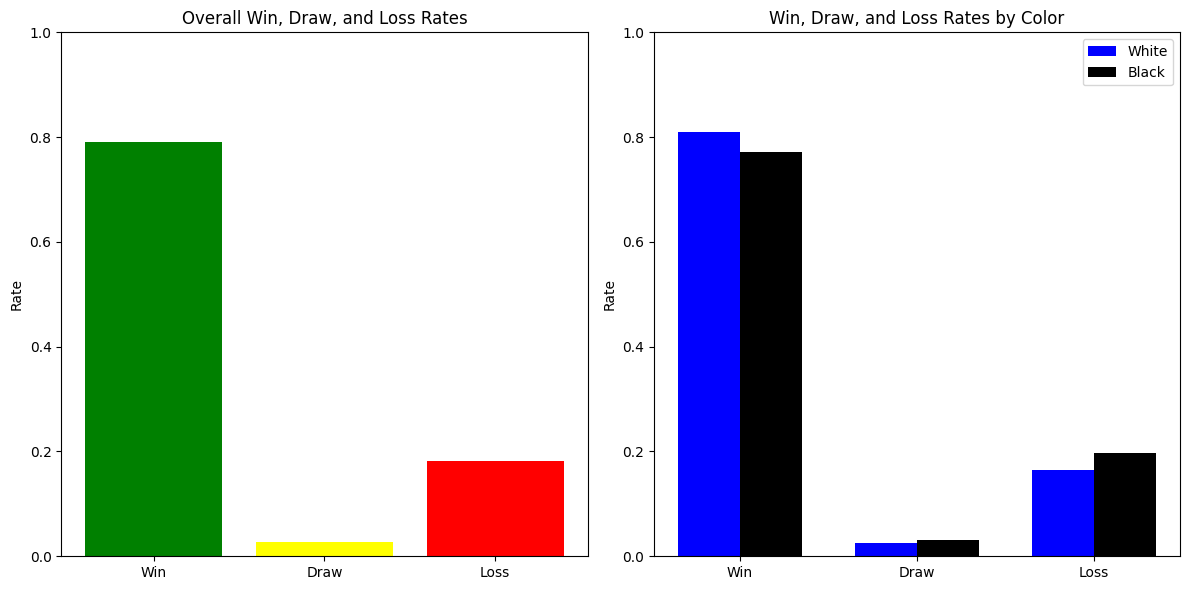

In [3]:
# Load the CSV data
filename = 'hikaru_all_games.csv'
df = pd.read_csv(filename)

# Calculate overall statistics
total_games = len(df)
win_rate = len(df[df['Result'] == 'win']) / total_games
draw_rate = len(df[df['Result'] == 'draw']) / total_games
loss_rate = len(df[df['Result'] == 'lose']) / total_games

# Calculate statistics by color
white_games = df[df['Color'] == 'white']
black_games = df[df['Color'] == 'black']

white_win_rate = len(white_games[white_games['Result'] == 'win']) / len(white_games)
white_draw_rate = len(white_games[white_games['Result'] == 'draw']) / len(white_games)
white_loss_rate = len(white_games[white_games['Result'] == 'lose']) / len(white_games)

black_win_rate = len(black_games[black_games['Result'] == 'win']) / len(black_games)
black_draw_rate = len(black_games[black_games['Result'] == 'draw']) / len(black_games)
black_loss_rate = len(black_games[black_games['Result'] == 'lose']) / len(black_games)

# Print overall statistics
print(f"Total games: {total_games}")
print(f"Win rate: {win_rate:.2%}")
print(f"Draw rate: {draw_rate:.2%}")
print(f"Loss rate: {loss_rate:.2%}")

# Print statistics by color
print("\nAs White:")
print(f"Total games as White: {len(white_games)}")
print(f"Win rate: {white_win_rate:.2%}")
print(f"Draw rate: {white_draw_rate:.2%}")
print(f"Loss rate: {white_loss_rate:.2%}")

print("\nAs Black:")
print(f"Total games as Black: {len(black_games)}")
print(f"Win rate: {black_win_rate:.2%}")
print(f"Draw rate: {black_draw_rate:.2%}")
print(f"Loss rate: {black_loss_rate:.2%}")

# Plot overall win, draw, and loss rates
labels = ['Win', 'Draw', 'Loss']
overall_rates = [win_rate, draw_rate, loss_rate]
white_rates = [white_win_rate, white_draw_rate, white_loss_rate]
black_rates = [black_win_rate, black_draw_rate, black_loss_rate]

x = range(len(labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Overall plot
ax[0].bar(x, overall_rates, color=['green', 'yellow', 'red'])
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_ylim(0, 1)
ax[0].set_ylabel('Rate')
ax[0].set_title('Overall Win, Draw, and Loss Rates')

# Win rates by color
bar_width = 0.35
ax[1].bar(x, white_rates, bar_width, label='White', color='blue')
ax[1].bar([p + bar_width for p in x], black_rates, bar_width, label='Black', color='black')
ax[1].set_xticks([p + bar_width / 2 for p in x])
ax[1].set_xticklabels(labels)
ax[1].set_ylim(0, 1)
ax[1].set_ylabel('Rate')
ax[1].set_title('Win, Draw, and Loss Rates by Color')
ax[1].legend()

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import chess
import chess.pgn
import chess.engine
from io import StringIO
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [5]:
# Load the CSV data
filename = 'hikaru_all_games.csv'
df = pd.read_csv(filename)

# Function to convert board to features
def board_to_features(board):
    features = np.zeros((8, 8, 12), dtype=np.float32)
    for i in range(64):
        piece = board.piece_at(i)
        if piece:
            features[i // 8, i % 8, piece.piece_type - 1 + (6 if piece.color == chess.BLACK else 0)] = 1
    return features

# Prepare the dataset
X, y = [], []
successful_parses = 0
total_games = len(df)

for index, row in df.iterrows():
    result, color, moves = row['Result'], row['Color'], row['Moves']
    pgn_str = f"[Result \"{result}\"]\n1. {moves.replace(' ', ' 1. ')}"
    
    try:
        game = chess.pgn.read_game(StringIO(pgn_str))
        if game is None:
            continue  # Skip if the game cannot be parsed
        board = game.board()
        
        for move in game.mainline_moves():
            if (board.turn == chess.WHITE and color == 'white') or (board.turn == chess.BLACK and color == 'black'):
                X.append(board_to_features(board))
                y.append(move.uci())
            board.push(move)
        successful_parses += 1
    except Exception as e:
        print(f"Error parsing game at index {index}: {e}")
        continue  # Skip games that cannot be parsed

# Print the number of successfully parsed games and the success percentage
print(f"Successfully parsed games: {successful_parses}")
print(f"Total games: {total_games}")
print(f"Success percentage: {successful_parses / total_games * 100:.2f}%")


illegal san: 'c6' in rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1 while parsing <Game at 0x1aa5ccbbb00 ('?' vs. '?', '????.??.??' at '?')>
illegal san: 'd5' in rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1 while parsing <Game at 0x1aa6cc654c0 ('?' vs. '?', '????.??.??' at '?')>
illegal san: 'Kd8' in r1bqkbnr/ppNppppp/8/2p5/2Pn4/8/PP1PPPPP/R1BQKBNR b KQkq - 5 4 while parsing <Game at 0x1aa6cbd7440 ('?' vs. '?', '????.??.??' at '?')>
illegal san: 'Ne3' in rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2 while parsing <Game at 0x1aa72f61cd0 ('?' vs. '?', '????.??.??' at '?')>
illegal san: 'Nb3' in r2qkbnr/1bpppp1p/ppn3p1/8/PP4P1/2N5/2PPPPBP/R1BQK1NR w KQkq - 0 6 while parsing <Game at 0x1aa7fe5a7e0 ('?' vs. '?', '????.??.??' at '?')>
illegal san: 'Nfe6' in rnbqkbnr/pppp1ppp/8/4p3/2B1P3/8/PPPP1PPP/RNBQK1NR b KQkq - 1 2 while parsing <Game at 0x1aa139b7920 ('?' vs. '?', '????.??.??' at '?')>
illegal san: 'Nab6' in rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQK

Successfully parsed games: 57781
Total games: 57781
Success percentage: 100.00%


In [6]:
# Convert to numpy arrays and ensure correct data types
X = np.array(X, dtype=np.float32)
y = np.array(y)

# Debugging statements to check shapes and types
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

# Encode the moves
unique_moves = sorted(set(y))
move_encoder = {uci: idx for idx, uci in enumerate(unique_moves)}
y_encoded = np.array([move_encoder[uci] for uci in y], dtype=np.int32)

# Check the encoding
print(f"Unique moves: {len(unique_moves)}")
print(f"Example encoded move: {y_encoded[0]}")

Shape of X: (2403286, 8, 8, 12)
Shape of y: (2403286,)
Type of X: <class 'numpy.ndarray'>
Type of y: <class 'numpy.ndarray'>
Unique moves: 1878
Example encoded move: 985


In [10]:
model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 12), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(len(move_encoder), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 974,486 (3.72 MB)

 Trainable params: 972,054 (3.71 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [12]:
# Learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return float(lr * tf.math.exp(-0.1))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = callbacks.LearningRateScheduler(scheduler)

# Train the model with enhanced training process
history = model.fit(
    X, y_encoded,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping, lr_scheduler]
)

# Save the model
model.save('hikaru_chess_model_v2.h5')

Epoch 1/50
15021/15021 ━━━━━━━━━━━━━━━━━━━━ 203s 13ms/step - accuracy: 0.1529 - loss: 4.7987 - val_accuracy: 0.1775 - val_loss: 4.4722 - learning_rate: 0.0010
Epoch 2/50
15021/15021 ━━━━━━━━━━━━━━━━━━━━ 204s 14ms/step - accuracy: 0.1537 - loss: 4.7835 - val_accuracy: 0.1791 - val_loss: 4.4418 - learning_rate: 0.0010
Epoch 3/50
15021/15021 ━━━━━━━━━━━━━━━━━━━━ 205s 14ms/step - accuracy: 0.1546 - loss: 4.7619 - val_accuracy: 0.1807 - val_loss: 4.4206 - learning_rate: 0.0010
Epoch 4/50
15021/15021 ━━━━━━━━━━━━━━━━━━━━ 206s 14ms/step - accuracy: 0.1557 - loss: 4.7442 - val_accuracy: 0.1804 - val_loss: 4.4060 - learning_rate: 0.0010
Epoch 5/50
15021/15021 ━━━━━━━━━━━━━━━━━━━━ 210s 14ms/step - accuracy: 0.1570 - loss: 4.7311 - val_accuracy: 0.1820 - val_loss: 4.3903 - learning_rate: 0.0010
Epoch 6/50
15021/15021 ━━━━━━━━━━━━━━━━━━━━ 216s 14ms/step - accuracy: 0.1576 - loss: 4.7159 - val_accuracy: 0.1769 - val_loss: 4.3674 - learning_rate: 0.0010
Epoch 7/50
15021/15021 ━━━━━━━━━━━━━━━━━━━━ 22

In [13]:
# Save the move encoder
np.save('move_encoder_classes_v2.npy', np.array(list(move_encoder.keys())))

In [14]:
# Function to convert model prediction back to move
def predict_move(board, model, move_encoder):
    features = board_to_features(board)
    features = np.expand_dims(features, axis=0)
    preds = model.predict(features)
    sorted_indices = np.argsort(preds[0])[::-1]  # Indices of moves sorted by probability
    
    for move_idx in sorted_indices:
        move_uci = [uci for uci, idx in move_encoder.items() if idx == move_idx][0]
        move = chess.Move.from_uci(move_uci)
        if move in board.legal_moves:
            return move
    
    return None  # If no legal move is found

# Evaluate the trained model
board = chess.Board()
while not board.is_game_over():
    move = predict_move(board, model, move_encoder)
    if move is None:
        print("No legal move found.")
        break
    board.push(move)
    print(board)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
r n b q k b n r
p p p p p p . p
. . . . . . p .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
r n b q k b n r
p p p p p p . p
. . . . . . p .
. . . . . . . .
. . . . P . . .
. . N . . . . .
P P P P . P P P
R . B Q K B N R
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
r n b q k . n r
p p p p p p b p
. . . . . . p .
. . . . . . . .
. . . . P . . .
. . N . . . . .
P P P P . P P P
R . B Q K B N R
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
r n b q k . n r
p p p p p p b p
. . . . . . p .
. . . . . . . .
. . . P P . . .
. . N . . . . .
P P P . . P P P
R . B Q K B N R
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
r n b q k . n r
. p p p p p b p
p . . . . . p .
. . . . . . . .
. . . P P . . .
. . N . . . . .
P P P . . P P P
R . B Q K B N R
1/1 